In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


Load the processed dataset.

In [2]:
X_train = np.load("../Processed_Data/X_train.npy")
X_val   = np.load("../Processed_Data/X_val.npy")
X_test  = np.load("../Processed_Data/X_test.npy")

y_train = np.load("../Processed_Data/y_train.npy")
y_val   = np.load("../Processed_Data/y_val.npy")
y_test  = np.load("../Processed_Data/y_test.npy")

Check the shapes.

Convert to PyTorch tensors.

In [3]:
X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)
y_test = torch.LongTensor(y_test)

Create DataLoaders.

In [4]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False,
)

Step 7: Build the EEG Conformer Model

In [5]:
import torch
import torch.nn as nn

Step 7.1: EEG Conformer Class

In [9]:
import torch
import torch.nn as nn

class EEGConformer(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        # ---------------------------
        # Patch Embedding
        # ---------------------------
        self.patch_embedding = nn.Sequential(

            # Temporal Convolution
            nn.Conv2d(
                in_channels=1,
                out_channels=40,
                kernel_size=(1, 25),
                padding=(0, 12),
                bias=False
            ),

            nn.BatchNorm2d(40),

            # Spatial Convolution
            nn.Conv2d(
                in_channels=40,
                out_channels=40,
                kernel_size=(14, 1),
                bias=False
            ),

            nn.BatchNorm2d(40),

            nn.ELU(),

            nn.AvgPool2d(kernel_size=(1, 8)),

            nn.Dropout(0.5)
        )

        # ---------------------------
        # Transformer Encoder
        # ---------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=40,
            nhead=4,
            dim_feedforward=128,
            dropout=0.5,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        # ---------------------------
        # Classifier
        # ---------------------------
        self.classifier = nn.Linear(
            in_features=40,
            out_features=num_classes
        )

    # ===============================
    # Forward Function
    # ===============================
    def forward(self, x):

        # x shape: (batch, 14, 512)

        x = x.unsqueeze(1)

        # (batch,1,14,512)

        x = self.patch_embedding(x)

        # (batch,40,1,64)

        x = x.squeeze(2)

        # (batch,40,64)

        x = x.permute(0, 2, 1)

        # (batch,64,40)

        x = self.transformer(x)

        # (batch,64,40)

        x = x.mean(dim=1)

        # (batch,40)

        x = self.classifier(x)

        # (batch,2)

        return x

Step 8: Create the Model

In [10]:
model = EEGConformer(num_classes=2).to(device)

print(model)

EEGConformer(
  (patch_embedding): Sequential(
    (0): Conv2d(1, 40, kernel_size=(1, 25), stride=(1, 1), padding=(0, 12), bias=False)
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(40, 40, kernel_size=(14, 1), stride=(1, 1), bias=False)
    (3): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=40, out_features=40, bias=True)
        )
        (linear1): Linear(in_features=40, out_features=128, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=128, out_features=40, bias=True)
        (norm1): LayerNorm((40,), eps=

Step 9: Test the Model

In [11]:
sample = X_train[:32].to(device)

output = model(sample)

print(output.shape)

torch.Size([32, 2])


Step 10: Define the Loss Function and Optimizer

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Step 11: Variables to Save the Best Model

In [14]:
num_epochs = 100

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

Step 12: Training Loop

In [15]:
for epoch in range(num_epochs):

    # ==========================
    # Training
    # ==========================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ==========================
    # Validation
    # ==========================
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_eegconformer.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/100] | Train Loss: 0.6002 | Train Acc: 0.6552 | Val Loss: 1.4415 | Val Acc: 0.4130
Epoch [2/100] | Train Loss: 0.5311 | Train Acc: 0.7427 | Val Loss: 1.5030 | Val Acc: 0.5978
Epoch [3/100] | Train Loss: 0.4894 | Train Acc: 0.7341 | Val Loss: 1.8986 | Val Acc: 0.4076
Epoch [4/100] | Train Loss: 0.4891 | Train Acc: 0.7479 | Val Loss: 1.7612 | Val Acc: 0.4130
Epoch [5/100] | Train Loss: 0.4704 | Train Acc: 0.7564 | Val Loss: 1.9051 | Val Acc: 0.4239
Epoch [6/100] | Train Loss: 0.4859 | Train Acc: 0.7496 | Val Loss: 2.0242 | Val Acc: 0.4239
Epoch [7/100] | Train Loss: 0.4773 | Train Acc: 0.7479 | Val Loss: 2.0322 | Val Acc: 0.4239
Epoch [8/100] | Train Loss: 0.4826 | Train Acc: 0.7410 | Val Loss: 1.9471 | Val Acc: 0.4130
Epoch [9/100] | Train Loss: 0.4576 | Train Acc: 0.7719 | Val Loss: 2.2137 | Val Acc: 0.4076
Epoch [10/100] | Train Loss: 0.4552 | Train Acc: 0.7684 | Val Loss: 2.1284 | Val Acc: 0.4185
Epoch [11/100] | Train Loss: 0.4622 | Train Acc: 0.7616 | Val Loss: 2.1372 | Va

Step 13: Load the Best Model

In [16]:
model = EEGConformer(num_classes=2).to(device)

model.load_state_dict(torch.load("best_eegconformer.pth"))

model.eval()

EEGConformer(
  (patch_embedding): Sequential(
    (0): Conv2d(1, 40, kernel_size=(1, 25), stride=(1, 1), padding=(0, 12), bias=False)
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(40, 40, kernel_size=(14, 1), stride=(1, 1), bias=False)
    (3): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=40, out_features=40, bias=True)
        )
        (linear1): Linear(in_features=40, out_features=128, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=128, out_features=40, bias=True)
        (norm1): LayerNorm((40,), eps=

Step 14: Make Predictions on the Test Set

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.numpy())

        y_pred.extend(predictions.cpu().numpy())

        y_prob.extend(probabilities[:,1].cpu().numpy())

Step 15: Calculate Performance Metrics

In [18]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

roc_auc = roc_auc_score(y_true, y_prob)

print("Test Accuracy :", round(accuracy,4))
print("Precision     :", round(precision,4))
print("Recall        :", round(recall,4))
print("F1-score      :", round(f1,4))
print("ROC-AUC       :", round(roc_auc,4))

Test Accuracy : 0.6667
Precision     : 0.6
Recall        : 1.0
F1-score      : 0.75
ROC-AUC       : 0.3573


Step 16: Classification Report

In [19]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50       111
           1       0.60      1.00      0.75       111

    accuracy                           0.67       222
   macro avg       0.80      0.67      0.62       222
weighted avg       0.80      0.67      0.62       222



Step 17: Confusion Matrix

In [20]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 37  74]
 [  0 111]]


Step 18: Plot the Confusion Matrix

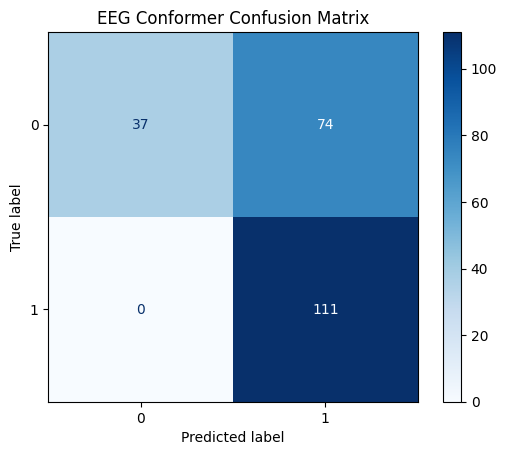

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0,1]
)

disp.plot(cmap="Blues")

plt.title("EEG Conformer Confusion Matrix")

plt.show()

Step 19: Plot the Learning Curves

Training & Validation Loss

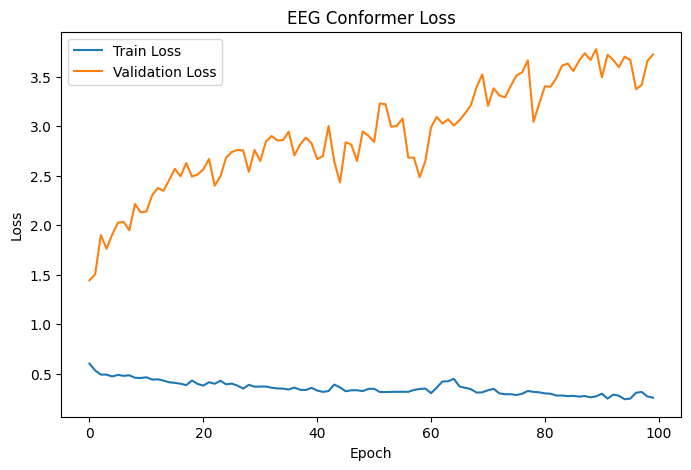

In [22]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EEG Conformer Loss")

plt.legend()

plt.show()

Training & Validation Accuracy

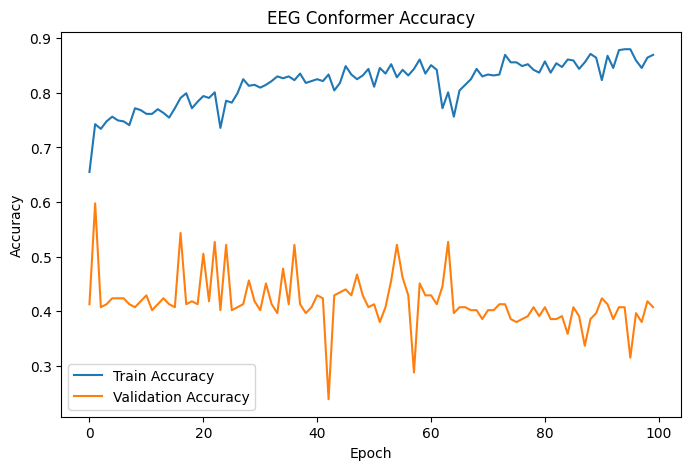

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("EEG Conformer Accuracy")

plt.legend()

plt.show()

Section: Improved EEG Conformer

In [24]:
# Improved EEG Conformer
# Positional Encoding + Early Stopping + LR Scheduler

Add Positional Encoding

In [ ]:
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self, seq_len=64, d_model=40):
        super().__init__()

        self.pos_embedding = nn.Parameter(
            torch.randn(1, seq_len, d_model)
        )

    def forward(self, x):
        return x + self.pos_embedding

Improved EEG Conformer

In [ ]:
class EEGConformer(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        # -----------------------------
        # Patch Embedding
        # -----------------------------
        self.patch_embedding = nn.Sequential(

            nn.Conv2d(
                1,
                40,
                kernel_size=(1,25),
                padding=(0,12),
                bias=False
            ),

            nn.BatchNorm2d(40),

            nn.Conv2d(
                40,
                40,
                kernel_size=(14,1),
                bias=False
            ),

            nn.BatchNorm2d(40),

            nn.ELU(),

            nn.AvgPool2d(kernel_size=(1,8)),

            nn.Dropout(0.3)
        )

        # -----------------------------
        # Positional Encoding
        # -----------------------------
        self.position = PositionalEncoding(
            seq_len=64,
            d_model=40
        )

        # -----------------------------
        # Transformer Encoder
        # -----------------------------
        encoder_layer = nn.TransformerEncoderLayer(

            d_model=40,

            nhead=4,

            dim_feedforward=128,

            dropout=0.3,

            batch_first=True

        )

        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=4

        )

        # -----------------------------
        # Classifier
        # -----------------------------
        self.classifier = nn.Linear(
            40,
            num_classes
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.patch_embedding(x)

        x = x.squeeze(2)

        x = x.permute(0,2,1)

        x = self.position(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.classifier(x)

        return x

Build Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EEGConformer(num_classes=2).to(device)

print(model)

Quick Shape Check

In [ ]:
sample = X_train[:32].to(device)

output = model(sample)

print(output.shape)

Loss, Optimizer & Scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=5,

    min_lr=1e-5

)

Training Variables

In [ ]:
num_epochs = 100

best_val_acc = 0

patience = 10

counter = 0

train_losses = []

val_losses = []

train_accs = []

val_accs = []

Improved Training Loop

In [ ]:
for epoch in range(num_epochs):

    ########################################
    # Training
    ########################################

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += y_batch.size(0)

        correct += (predicted==y_batch).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    ########################################
    # Validation
    ########################################

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs,y_batch)

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += y_batch.size(0)

            correct += (predicted==y_batch).sum().item()

    val_loss = running_loss / len(val_loader)

    val_acc = correct / total

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    ########################################
    # Scheduler
    ########################################

    scheduler.step(val_loss)

    ########################################
    # Save Best Model
    ########################################

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            "best_eegconformer_improved.pth"
        )

    else:

        counter += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )

    ########################################
    # Early Stopping
    ########################################

    if counter >= patience:

        print("\nEarly stopping triggered.")

        break

print("\nBest Validation Accuracy:", best_val_acc)